# Diffusion Inpainting Augmentation for Medical Image Classification

**Course**: CSC 578 — Advanced Deep Learning

**Description**:
In this assignment, you will investigate **diffusion-based data augmentation** for medical image classification. Medical datasets are often imbalanced, so a classifier may learn the majority class more easily and miss important minority-class cases. To study this, you will create an imbalanced **PneumoniaMNIST** training set, fine-tune a baseline CNN, compare it with traditional augmentation, and then use a pretrained diffusion denoiser to generate masked inpainted pneumonia samples for augmentation. Finally, you will compare all models using classification metrics, confusion matrices, and generated-image visualizations.

## Learning Objectives

By the end of this assignment, you will be able to:

- Build a complete **medical image classification** pipeline using **PneumoniaMNIST**.
- Create a controlled **class imbalance** only in the training set.
- Fine-tune CNN classifiers using **TensorFlow / Keras**.
- Apply and evaluate **traditional image augmentation** during training.
- Implement core diffusion sampling components: **noise schedule**, **reverse denoising step**, and **masked inpainting**.
- Adapt a pretrained diffusion denoiser through a short fine-tuning stage and use the generated pneumonia samples as training augmentation.
- Compare baseline, traditional augmentation, and diffusion-augmented models using classification metrics and visualizations.

**Estimated time:** ~2–3 hours on Colab (GPU recommended but not required).  
**Framework constraint:** **TensorFlow / Keras only** (no PyTorch).  
**Checkpoint note:** The provided checkpoints are used as starting points, but the notebook still includes fine-tuning, generation, evaluation, and comparison.

## Background: Diffusion Inpainting Augmentation Pipeline

Medical image datasets are often imbalanced. In this assignment, we simulate that problem by reducing the number of **pneumonia** images in the training set while keeping the validation and test sets unchanged.

The main question is:

```text
Can generated pneumonia-like training samples improve classification when the training set is imbalanced?
```

To answer this, we compare three models:

| Model | Training Data Used | Purpose |
| :--- | :--- | :--- |
| **Baseline CNN** | Imbalanced training set only | Measures performance without augmentation |
| **Traditional Augmentation CNN** | Imbalanced training set + image transformations | Tests standard label-preserving augmentation |
| **Diffusion-Augmented CNN** | Imbalanced training set + generated inpainted pneumonia samples | Tests whether generated minority-class samples help |

**Step 1: Create an imbalanced dataset**  
We load PneumoniaMNIST and keep all normal training images but only a smaller fraction of pneumonia training images. Validation and test data are not modified.

**Step 2: Fine-tune a baseline CNN**  
The baseline model starts from a provided checkpoint and is fine-tuned on the imbalanced training set. This shows how the classifier performs when pneumonia examples are limited.

**Step 3: Fine-tune a traditional augmentation CNN**  
Traditional augmentation applies small transformations such as rotation, translation, zoom, and contrast changes. These transformations help generalization, but they only modify existing images.

**Step 4: Fine-tune a diffusion denoiser**  
The denoiser starts from a provided checkpoint and is briefly fine-tuned on pneumonia images from the imbalanced training set. During diffusion training, the model learns to predict the noise added to an image at a random timestep.

**Step 5: Generate inpainted pneumonia samples**  
Masked inpainting keeps most of the original image fixed and regenerates only a selected region. The generated images are added only to the training set.

```text
[Original pneumonia image + mask + diffusion denoiser]
                          ↓
         Generated inpainted pneumonia image
```

**Step 6: Compare all models**  
All three classifier models are evaluated on the same unchanged test set using accuracy, precision, recall, F1-score, confusion matrices, and generated-image visualizations.

## Setup

We will first import the required libraries and prepare the shared configuration for the notebook.

The setup includes:

- `tensorflow` / `keras`: for building, loading, fine-tuning, and evaluating models.
- `numpy`: for array operations and class balancing.
- `matplotlib`: for visualizing samples, generated images, and confusion matrices.
- `sklearn.metrics`: for classification reports and evaluation scores.
- `gdown`: for downloading the provided checkpoint folder.

The provided checkpoints are used as **starting points**, not final answers. Each model is still fine-tuned and evaluated in this notebook.

In [ ]:
import os, random
import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
Keras: 3.13.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import gdown
import os

os.makedirs("/content/checkpoints", exist_ok=True)

folder_url = "https://drive.google.com/drive/folders/1rQ4Z2zYd6ublf2TVP5Q8ElvX_MCxCtiF?usp=drive_link"

gdown.download_folder(
    folder_url,
    output="/content/checkpoints",
    quiet=False
)

Retrieving folder contents


Processing file 1Q6VQ4uJfgs65Kbriez4hKCxpC9aT1_Dk baseline_cnn_final.keras
Processing file 1SDD-dKNM0iJD04FBSHFtxpFZNfvzLpih denoiser_final.keras
Processing file 1lu3aeLylCPWm8ZSBcJ9haTEFsIFkQpr7 denoiser_student_final_epoch1050.keras
Processing file 1rhUhWzgKu1SvOJcQZAhs7N7KbDIGlLID diffusion_aug_cnn_final.keras
Processing file 127Y2ynnc-MUsRP4Fc7iHnES37axK79mi generated_images.npy
Processing file 1fP-dnRwv5B6NRwGwBysSy-kRYa0rSq6j generated_labels.npy
Processing file 1BJjvJBaPggZGOEaSZN0058BVAV77cee5 traditional_aug_cnn_final.keras


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Q6VQ4uJfgs65Kbriez4hKCxpC9aT1_Dk
To: /content/checkpoints/baseline_cnn_final.keras
100%|██████████| 5.14M/5.14M [00:00<00:00, 125MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1SDD-dKNM0iJD04FBSHFtxpFZNfvzLpih
From (redirected): https://drive.google.com/uc?id=1SDD-dKNM0iJD04FBSHFtxpFZNfvzLpih&confirm=t&uuid=00ae39be-a3d3-4642-80a0-0e27d1ae9a2d
To: /content/checkpoints/denoiser_final.keras
100%|██████████| 114M/114M [00:00<00:00, 145MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1lu3aeLylCPWm8ZSBcJ9haTEFsIFkQpr7
From (redirected): https://drive.google.com/uc?id=1lu3aeLylCPWm8ZSBcJ9haTEFsIFkQpr7&confirm=t&uuid=3b667d37-55cf-4bd6-ae21-76409327d23f
To: /content/checkpoints/denoiser_student_final_epoch1050.keras
100%|██████████| 114M/114M [00:00<00:00, 167MB/s]
Downloading...
From: https://dr

['/content/checkpoints/baseline_cnn_final.keras',
 '/content/checkpoints/denoiser_final.keras',
 '/content/checkpoints/denoiser_student_final_epoch1050.keras',
 '/content/checkpoints/diffusion_aug_cnn_final.keras',
 '/content/checkpoints/generated_images.npy',
 '/content/checkpoints/generated_labels.npy',
 '/content/checkpoints/traditional_aug_cnn_final.keras']

## Global Configuration

This cell defines the main constants used throughout the notebook: random seed, image size, batch size, fine-tuning settings, imbalance ratio, diffusion settings, augmentation strength, and checkpoint paths.

In [ ]:
# ── Reproducibility ──
SEED = 42

def reset_all_seeds(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    try:
        keras.utils.set_random_seed(seed)
    except Exception:
        pass

reset_all_seeds(SEED)

# ── Core constants ──
IMG_SIZE = 64
BATCH_SIZE = 32
KEY_FINE_TUNE_EPOCHS = 5
KEY_CLASSIFIER_LR = 5e-7
KEY_DENOISER_LR = 2e-6

MINORITY_CLASS = 1                 # Pneumonia, verified against MedMNIST INFO below
MINORITY_KEEP_FRACTION = 0.20      # Artificially keep 20% of pneumonia samples in train
TARGET_MINORITY_MULTIPLIER = 2     # Generate enough samples to double current minority count

DIFFUSION_TIMESTEPS = 50
NOISE_BETA_START = 1e-4
NOISE_BETA_END = 0.02
INPAINT_MASK_FRAC = 0.25

# ── Final gentle traditional augmentation config ──
TRAD_ROTATION_FACTOR = 0.025       # about ±9 degrees
TRAD_TRANSLATION_FACTOR = 0.040    # about ±4% shift
TRAD_ZOOM_FACTOR = 0.050           # about ±5% zoom
TRAD_CONTRAST_FACTOR = 0.10        # mild contrast variation
TRAD_FILL_MODE = "nearest"         # avoids artificial black borders

# ── Provided checkpoint paths used by this assignment notebook ──
CHECKPOINT_DIR = "checkpoints"
DENOISER_PRETRAINED_PATH = os.path.join(CHECKPOINT_DIR, "denoiser_final.keras")
BASELINE_PRETRAINED_PATH = os.path.join(CHECKPOINT_DIR, "baseline_cnn_final.keras")
TRAD_AUG_PRETRAINED_PATH = os.path.join(CHECKPOINT_DIR, "traditional_aug_cnn_final.keras")
DIFFUSION_AUG_PRETRAINED_PATH = os.path.join(CHECKPOINT_DIR, "diffusion_aug_cnn_final.keras")


print("Checkpoint directory:", os.path.abspath(CHECKPOINT_DIR))
print("Fine-tuning epochs:", KEY_FINE_TUNE_EPOCHS)


Checkpoint directory: /content/checkpoints
Fine-tuning epochs: 5


In [ ]:
required_checkpoints = [
    DENOISER_PRETRAINED_PATH,
    BASELINE_PRETRAINED_PATH,
    TRAD_AUG_PRETRAINED_PATH,
    DIFFUSION_AUG_PRETRAINED_PATH,
]

missing = [p for p in required_checkpoints if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(
        "Missing required checkpoint(s):\n" + "\n".join(f"  - {p}" for p in missing) +
        "\n\nCreate or upload the complete checkpoints/ folder before running this notebook. "
        "This notebook uses only model checkpoints and computes its own metrics from the current run."
    )

print("✓ All required model checkpoints found.")
for p in required_checkpoints:
    print(f"  - {p}")


✓ All required model checkpoints found.
  - checkpoints/denoiser_final.keras
  - checkpoints/baseline_cnn_final.keras
  - checkpoints/traditional_aug_cnn_final.keras
  - checkpoints/diffusion_aug_cnn_final.keras


## Provided Helper Functions

These helper functions are provided to keep the assignment focused on the main deep learning pipeline.

They handle:

- class distribution plots
- image grids and sample visualization
- confusion matrices
- prediction examples
- dataset batching
- checkpoint validation
- model evaluation metrics

In [ ]:
# ── Plotting helpers ──
def plot_class_distribution(labels, title="Class Distribution"):
    counts = np.bincount(labels.astype(np.int32), minlength=2)
    fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(["normal (0)", "pneumonia (1)"], counts)
    for i, v in enumerate(counts):
        ax.text(i, v + max(5, counts.max() * 0.01), str(v), ha="center", fontweight="bold")
    ax.set_title(title)
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()


def plot_image_grid(images, n=8, title="Images"):
    n = min(n, len(images))
    cols = min(n, 8)
    rows = max(1, (n + cols - 1) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
    axes = np.array(axes).reshape(-1)
    for i in range(n):
        img = images[i].numpy().squeeze() if hasattr(images[i], "numpy") else np.squeeze(images[i])
        axes[i].imshow(img, cmap="gray")
        axes[i].axis("off")
    for i in range(n, len(axes)):
        axes[i].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(cm, model_name="Model"):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["normal", "pneumonia"])
    ax.set_yticklabels(["normal", "pneumonia"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(model_name)
    threshold = cm.max() / 2 if cm.size and cm.max() > 0 else 0
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, str(cm[i][j]), ha="center", va="center",
                color="white" if cm[i][j] > threshold else "black", fontsize=14
            )
    plt.tight_layout()
    plt.show()


def plot_original_samples(images, labels, n=8, title="Original Samples"):
    label_names = {0: "normal", 1: "pneumonia"}
    n = min(n, len(images))
    cols = min(n, 8)
    rows = max(1, (n + cols - 1) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 2))
    axes = np.array(axes).reshape(-1)
    for i in range(n):
        axes[i].imshow(np.squeeze(images[i]), cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(label_names.get(int(labels[i]), str(labels[i])), fontsize=9)
    for i in range(n, len(axes)):
        axes[i].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_traditional_aug_examples(images, aug_pipeline, n=4, repeats=3):
    n = min(n, len(images))
    fig, axes = plt.subplots(n, repeats + 1, figsize=((repeats + 1) * 1.8, n * 1.8))
    if n == 1:
        axes = axes[np.newaxis, :]
    for i in range(n):
        axes[i, 0].imshow(np.squeeze(images[i]), cmap="gray")
        axes[i, 0].axis("off")
        if i == 0:
            axes[i, 0].set_title("Original", fontsize=9)
        for j in range(repeats):
            aug = aug_pipeline(images[i:i + 1], training=True)[0]
            axes[i, j + 1].imshow(np.squeeze(aug.numpy()), cmap="gray")
            axes[i, j + 1].axis("off")
            if i == 0:
                axes[i, j + 1].set_title(f"Aug {j + 1}", fontsize=9)
    fig.suptitle("Traditional Augmentation Examples (training-time only)")
    plt.tight_layout()
    plt.show()


def plot_prediction_examples(model, images, labels, n=8, title="Prediction Examples"):
    label_names = {0: "normal", 1: "pneumonia"}
    n = min(n, len(images))
    preds_prob = model.predict(images[:n].astype(np.float32), verbose=0).squeeze()
    preds = (preds_prob >= 0.5).astype(int)
    cols = min(n, 8)
    rows = max(1, (n + cols - 1) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.5))
    axes = np.array(axes).reshape(-1)
    for i in range(n):
        axes[i].imshow(np.squeeze(images[i]), cmap="gray")
        axes[i].axis("off")
        true_lbl = label_names.get(int(labels[i]), str(labels[i]))
        pred_lbl = label_names.get(int(preds[i]), str(preds[i]))
        color = "green" if preds[i] == int(labels[i]) else "red"
        axes[i].set_title(f"T:{true_lbl}\nP:{pred_lbl} ({preds_prob[i]:.2f})", fontsize=8, color=color)
    for i in range(n, len(axes)):
        axes[i].axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


# ── tf.data ──
def make_tf_dataset(images, labels, batch_size=BATCH_SIZE, shuffle=True, augment_fn=None):
    images = images.astype(np.float32)
    labels = labels.astype(np.float32)
    ds = tf.data.Dataset.from_tensor_slices((images, labels))
    if shuffle:
        ds = ds.shuffle(len(images), seed=SEED, reshuffle_each_iteration=True)
    if augment_fn is not None:
        ds = ds.map(lambda x, y: (augment_fn(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


# ── Evaluation ──
def evaluate_model(model, images, labels, model_name="Model"):
    preds_prob = model.predict(images.astype(np.float32), verbose=0).squeeze()
    preds = (preds_prob >= 0.5).astype(np.int32)
    labels = labels.astype(np.int32)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    prec = precision_score(labels, preds, pos_label=MINORITY_CLASS, zero_division=0)
    rec = recall_score(labels, preds, pos_label=MINORITY_CLASS, zero_division=0)
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    print(f"\n{'=' * 50}\n  {model_name} — Test Evaluation\n{'=' * 50}")
    print(f"  Accuracy: {acc:.4f}  Macro-F1: {f1:.4f}")
    print(f"  Minority Precision: {prec:.4f}  Minority Recall: {rec:.4f}")
    print(classification_report(labels, preds, target_names=["normal", "pneumonia"], zero_division=0))
    return {
        "accuracy": float(acc),
        "macro_f1": float(f1),
        "minority_precision": float(prec),
        "minority_recall": float(rec),
        "confusion_matrix": cm.tolist(),
    }


# ── Checkpoint validation (light; does not change saved checkpoints) ──
def validate_checkpoint(path, is_denoiser=False):
    assert os.path.exists(path), f"Missing checkpoint: {path}"
    tmp = keras.saving.load_model(path)
    print(f"  ✓ Loaded {path}")
    if is_denoiser:
        d_img = np.random.rand(2, IMG_SIZE, IMG_SIZE, 1).astype(np.float32)
        d_t = np.array([0, 1], dtype=np.int32)
        pred = tmp.predict([d_img, d_t], verbose=0)
        assert pred.shape == (2, IMG_SIZE, IMG_SIZE, 1)
        assert np.all(np.isfinite(pred))
    else:
        d = np.random.rand(2, IMG_SIZE, IMG_SIZE, 1).astype(np.float32)
        pred = tmp.predict(d, verbose=0)
        assert pred.shape == (2, 1)
        assert np.all(np.isfinite(pred))
        assert np.all((pred >= 0) & (pred <= 1))
    print(f"  ✓ Validated {path}")
    del tmp


def compile_classifier_for_key_finetune(model):
    for layer in model.layers:
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(KEY_CLASSIFIER_LR),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def plot_augmentation_strategy_comparison(source_images, aug_pipeline, generated_images, n=6):
    """Compare original, traditional augmentation, and diffusion-generated minority examples.

    The traditional column is an augmented version of the original image in the same row.
    The diffusion column is sampled from the generated minority-image pool, so it shows the
    diffusion augmentation distribution rather than a strict one-to-one transform of the same row.
    """
    n = min(n, len(source_images), len(generated_images))
    if n == 0:
        print("No images available for augmentation strategy comparison.")
        return

    fig, axes = plt.subplots(n, 3, figsize=(7.5, 2.2 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for i in range(n):
        original = np.squeeze(source_images[i])
        traditional = aug_pipeline(source_images[i:i + 1], training=True)[0].numpy()
        diffusion = generated_images[i]

        axes[i, 0].imshow(original, cmap="gray")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(np.squeeze(np.clip(traditional, 0.0, 1.0)), cmap="gray")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(np.squeeze(np.clip(diffusion, 0.0, 1.0)), cmap="gray")
        axes[i, 2].axis("off")

    axes[0, 0].set_title("Original Minority", fontsize=10)
    axes[0, 1].set_title("Traditional Aug", fontsize=10)
    axes[0, 2].set_title("Diffusion Generated", fontsize=10)

    fig.suptitle(
        "Augmentation Strategy Comparison\n"
        "Traditional = same source image transformed; Diffusion = generated minority samples",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()



## Part 1 — Load PneumoniaMNIST and Create Artificial Imbalance [10 pts]

In this part, you will load PneumoniaMNIST, preprocess the images, and create an imbalanced training set by reducing the number of pneumonia samples.

**Task (10 pts total):**

- **1.1 Load and preprocess PneumoniaMNIST [5 pts]**
- **1.2 Create the imbalanced training set [5 pts]**

Only the training set should be imbalanced. Validation and test sets should remain unchanged.

In [ ]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.0 MB/s eta 0:00:00


### 1.1 Load and Preprocess PneumoniaMNIST [5 pts]

In this section, you will load and preprocess the `PneumoniaMNIST` dataset from the `medmnist` package. This dataset contains chest X-ray images labeled as either **normal** or **pneumonia**, making it a binary image classification task.

We first retrieve metadata about the dataset using `INFO`, which provides information such as the label mapping. We then verify that the selected `MINORITY_CLASS` corresponds to the `"pneumonia"` label using an `assert` statement.

Next, we load the dataset splits (`train`, `val`, and `test`) using `PneumoniaMNIST`. Each image is converted to `float32` format and normalized to the range $[0,1]$ by dividing by 255. Since some images may not include a channel dimension, we add one when necessary so that all images have shape `(H, W, 1)`.

If the requested image size is not directly supported by the dataset loader, we resize the images manually using `tf.image.resize`.

Finally, we store the processed images and labels for each split in a dictionary and unpack them into separate training, validation, and testing variables.

**Task (5 pts):** Complete the dataset loading and preprocessing code.

The code should:

- extract the label mapping from `INFO["pneumoniamnist"]`
- verify that `MINORITY_CLASS` maps to `"pneumonia"`
- load the `train`, `val`, and `test` splits
- normalize pixel values to `[0, 1]`
- add a channel dimension when needed
- resize images manually if the requested `IMG_SIZE` is not directly supported
- store each processed split in the `splits` dictionary

Expected output: dataset shapes and class counts for each split.

In [ ]:
from medmnist import PneumoniaMNIST, INFO

info = INFO["pneumoniamnist"]
# TODO: extract the label mapping dictionary
label_map = info["label"]
print("Label mapping:", label_map)
# TODO: verify that MINORITY_CLASS maps to "pneumonia"
assert label_map[str(MINORITY_CLASS)] == "pneumonia", "MINORITY_CLASS mismatch!"

splits = {}
for split_name in ["train", "val", "test"]:
    try:
        # TODO: load the dataset split using IMG_SIZE
        # TODO: normalize images to the range [0,1]
        # TODO: add a channel dimension if the images are missing one
        ds = PneumoniaMNIST(split=split_name, download=True, size=IMG_SIZE)
        images = ds.imgs.astype(np.float32) / 255.0
        if images.ndim == 3: images = images[..., np.newaxis]
        print(f"  {split_name}: loaded at size={IMG_SIZE}")
    except Exception:
        # TODO: load the dataset without specifying size
        # TODO: normalize images to the range [0,1]
        # TODO: add a channel dimension if needed
        # TODO: resize images to IMG_SIZE x IMG_SIZE
        ds = PneumoniaMNIST(split=split_name, download=True)
        images = ds.imgs.astype(np.float32) / 255.0
        if images.ndim == 3: images = images[..., np.newaxis]
        images = tf.image.resize(images, [IMG_SIZE, IMG_SIZE]).numpy()
        print(f"  {split_name}: resized to {IMG_SIZE}×{IMG_SIZE}")
    # TODO: convert labels to int32
    # TODO: store the images and labels in the splits dictionary
    labels = ds.labels.squeeze().astype(np.int32)
    splits[split_name] = (images, labels)
    print(f"    shape={images.shape}, counts={np.bincount(labels)}")

train_images, train_labels = splits["train"]
val_images, val_labels = splits["val"]
test_images, test_labels = splits["test"]

Label mapping: {'0': 'normal', '1': 'pneumonia'}


100%|██████████| 20.6M/20.6M [00:03<00:00, 6.17MB/s]


  train: loaded at size=64
    shape=(4708, 64, 64, 1), counts=[1214 3494]
  val: loaded at size=64
    shape=(524, 64, 64, 1), counts=[135 389]
  test: loaded at size=64
    shape=(624, 64, 64, 1), counts=[234 390]


### 1.2 Create an Imbalanced Training Dataset [5 pts]

In many real-world machine learning problems, datasets are not perfectly balanced across classes. In this section, you will simulate this scenario by artificially reducing the number of examples belonging to the minority class.

The `create_imbalance` function takes a set of images and labels and selectively removes a portion of samples from the minority class specified by `MINORITY_CLASS`. The fraction of samples to keep is controlled by `MINORITY_KEEP_FRACTION`.

To ensure reproducibility, we initialize a NumPy random number generator using a fixed random seed. We then separate the dataset into minority-class and majority-class samples using boolean masks.

Next, we randomly select a subset of minority-class examples to keep while retaining all majority-class samples. The selected minority samples are combined back with the majority samples to create a new imbalanced dataset.

Finally, we shuffle the resulting dataset and compare the class distributions before and after imbalance creation using `np.bincount`.

**Task (5 pts):** Complete `create_imbalance(...)` where the function should:

- create masks for minority and majority classes
- randomly select a fixed fraction of minority-class samples
- combine selected minority samples with all majority samples
- shuffle the final imbalanced training set
- print class counts before and after imbalance creation

In [ ]:
def create_imbalance(images, labels, minority_class=MINORITY_CLASS,
                     keep_fraction=MINORITY_KEEP_FRACTION, seed=SEED):
    # TODO: initialize a NumPy random number generator
    # TODO: create boolean masks for minority and majority classes
    # TODO: extract minority-class images and labels
    # TODO: compute the number of minority samples to keep
    # TODO: randomly select minority-class indices without replacement
    # TODO: combine majority samples with the selected minority samples
    # TODO: create a random permutation for shuffling
    # return the shuffled images and labels

    rng = np.random.RandomState(seed)
    mi = labels == minority_class; ma = ~mi
    mi_imgs, mi_lbls = images[mi], labels[mi]
    n_keep = int(len(mi_imgs) * keep_fraction)
    idx = rng.choice(len(mi_imgs), n_keep, replace=False)
    out_imgs = np.concatenate([images[ma], mi_imgs[idx]])
    out_lbls = np.concatenate([labels[ma], mi_lbls[idx]])
    perm = rng.permutation(len(out_imgs))
    return out_imgs[perm], out_lbls[perm]

imb_train_images, imb_train_labels = create_imbalance(train_images, train_labels)
print(f"Before: {np.bincount(train_labels)}")
print(f"After:  {np.bincount(imb_train_labels)}")

Before: [1214 3494]
After:  [1214  698]


### 1.3 Visualize Samples and Class Distributions
Use the provided helper functions `plot_original_samples` to visualize the original samples and  `plot_class_distribution` to visualize the distribution before and after imbalance.

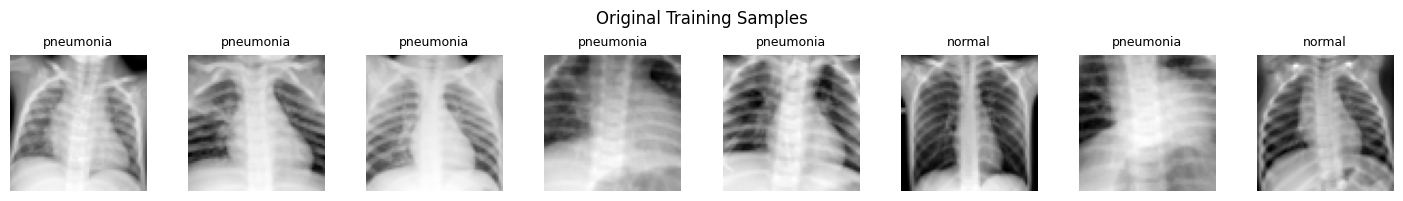

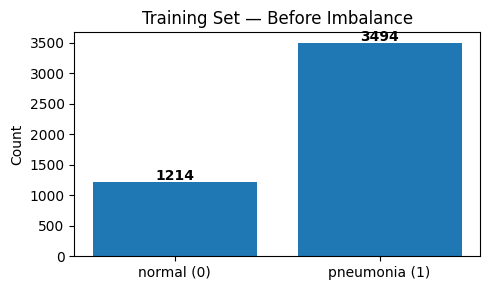

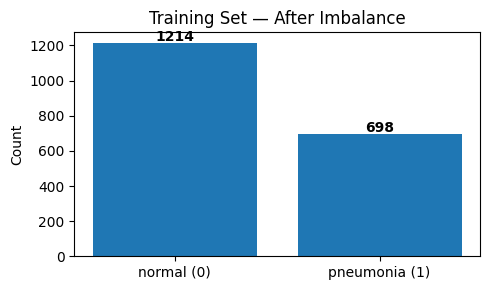

In [ ]:
plot_original_samples(train_images, train_labels, n=8, title="Original Training Samples")
plot_class_distribution(train_labels, "Training Set — Before Imbalance")
plot_class_distribution(imb_train_labels, "Training Set — After Imbalance")

## Part 2 — Baseline CNN with Checkpoint Loading and Fine-Tuning [10 pts]

In this part, you will build the baseline CNN classifier and fine-tune the provided baseline checkpoint on the artificially imbalanced training set.

This model gives us the reference point for the rest of the assignment. It shows how well a CNN performs when it only sees the reduced minority-class training set, without any augmentation.

**Task (10 pts total):**

- **2.1 Build or load the CNN classifier architecture [4 pts]**
- **2.2 Load the checkpoint and fine-tune the baseline model [4 pts]**
- **2.3 Evaluate and visualize baseline predictions [2 pts]**

### 2.1 Build the CNN Classifier Architecture [4 pts]

In this section, you will define the CNN architecture used for PneumoniaMNIST classification. The model takes a grayscale chest X-ray image as input and predicts whether it belongs to the **normal** or **pneumonia** class.

The network uses a simple stack of convolutional blocks. Each block extracts increasingly higher-level visual features using `Conv2D`, `BatchNormalization`, and pooling. After the convolutional layers, `GlobalAveragePooling2D` converts the feature maps into a compact vector, and the final sigmoid output produces a binary prediction.

**Task (4 pts):** Complete the `build_cnn` function.

The code should follow this exact CNN architecture:

- `Input(shape=(IMG_SIZE, IMG_SIZE, 1))`
- `Conv2D(32, 3, padding="same", activation="relu")` → `BatchNormalization()` → `MaxPooling2D(2)`
- `Conv2D(64, 3, padding="same", activation="relu")` → `BatchNormalization()` → `MaxPooling2D(2)`
- `Conv2D(128, 3, padding="same", activation="relu")` → `BatchNormalization()` → `MaxPooling2D(2)`
- `Conv2D(256, 3, padding="same", activation="relu")` → `BatchNormalization()` → `GlobalAveragePooling2D()`
- `Dense(128, activation="relu")`
- `Dropout(0.4)`
- `Dense(1, activation="sigmoid")`

Compile the model using:

- `optimizer=keras.optimizers.Adam(1e-3)`
- `loss="binary_crossentropy"`
- `metrics=["accuracy"]`

Use this fixed architecture so the classifier design is consistent with the provided checkpoint models used later in the notebook.

Expected output: a compiled Keras CNN model.

In [ ]:
# ==========================================================
# Task 2.1: Build CNN architecture [4 pts]
# ==========================================================

def build_cnn(img_size=IMG_SIZE):
    # TODO: create a Sequential model with input shape (img_size, img_size, 1)
    # TODO: add Conv2D blocks with filters 32, 64, 128, and 256 using kernel size 3 and ReLU
    # TODO: use BatchNormalization after each Conv2D layer
    # TODO: use MaxPooling2D(2) after the first three convolutional blocks
    # TODO: use GlobalAveragePooling2D after the final convolutional block
    # TODO: add Dense(128, activation="relu"), Dropout(0.4), and Dense(1, activation="sigmoid")
    # TODO: compile with Adam(1e-3), binary_crossentropy, and accuracy
    model = keras.Sequential([
        layers.Input(shape=(img_size, img_size, 1)),
        layers.Conv2D(32,3,padding="same",activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(64,3,padding="same",activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(128,3,padding="same",activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(2),
        layers.Conv2D(256,3,padding="same",activation="relu"),
        layers.BatchNormalization(), layers.GlobalAveragePooling2D(),
        layers.Dense(128,activation="relu"), layers.Dropout(0.4),
        layers.Dense(1,activation="sigmoid"),
    ], name="pneumonia_cnn")
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

### 2.2 Load the Baseline Checkpoint and Fine-Tune [4 pts]

In this section, you will load the provided baseline CNN `.keras` checkpoint and fine-tune it briefly on the imbalanced training set.

This checkpoint contains the full saved baseline model architecture and weights. It is not treated as the final answer because we still recompile the model and run a short fine-tuning stage so that the notebook includes a real training pipeline.

**Task (4 pts):** Load and fine-tune the baseline CNN.

The code should:

- reset random seeds for reproducibility
- validate and load the baseline checkpoint
- compile the model for gentle fine-tuning using the provided helper function
- create `tf.data` training and validation datasets
- fine-tune the model on the imbalanced training set

Expected output: training and validation loss/accuracy for the baseline model.

In [ ]:
# ==========================================================
# Task 2.2: Load baseline checkpoint and fine-tune [4 pts]
# ==========================================================

# TODO: reset random seeds before fine-tuning with SEED+1000
# TODO: validate that the baseline checkpoint can be loaded using validate_checkpoint()
# TODO: load the full saved baseline CNN model from the .keras checkpoint
# TODO: compile the loaded model for gentle fine-tuning using compile_classifier_for_key_finetune()
reset_all_seeds(SEED + 1000)
validate_checkpoint(BASELINE_PRETRAINED_PATH)
baseline_model = keras.saving.load_model(BASELINE_PRETRAINED_PATH)
baseline_model = compile_classifier_for_key_finetune(baseline_model)

# TODO: create training and validation tf.data datasets using make_tf_dataset()
train_ds = make_tf_dataset(imb_train_images, imb_train_labels)
val_ds = make_tf_dataset(val_images, val_labels, shuffle=False)

# TODO: fine-tune the model on the imbalanced training set
baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=KEY_FINE_TUNE_EPOCHS,
    verbose=1,
)


  ✓ Loaded checkpoints/baseline_cnn_final.keras
  ✓ Validated checkpoints/baseline_cnn_final.keras
Epoch 1/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.7882 - loss: 0.6805 - val_accuracy: 0.9103 - val_loss: 0.3497
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8368 - loss: 0.4871 - val_accuracy: 0.9275 - val_loss: 0.2784
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8828 - loss: 0.3440 - val_accuracy: 0.9351 - val_loss: 0.2299
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9111 - loss: 0.2471 - val_accuracy: 0.9447 - val_loss: 0.1967
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9341 - loss: 0.1883 - val_accuracy: 0.9485 - val_loss: 0.1734


### 2.3 Evaluate the Baseline Model [2 pts]

After fine-tuning, evaluate the baseline model on the unchanged test set. This result will be used later as the comparison point for traditional augmentation and diffusion augmentation.

**Task (2 pts):** Evaluate and visualize the baseline model that:
- compute baseline test metrics using `evaluate_model`
- plot the confusion matrix
- visualize a few test predictions

Expected output: baseline test metrics, classification report, confusion matrix, and example prediction images.


  Baseline CNN — Test Evaluation
  Accuracy: 0.8333  Macro-F1: 0.7996
  Minority Precision: 0.7918  Minority Recall: 0.9949
              precision    recall  f1-score   support

      normal       0.99      0.56      0.72       234
   pneumonia       0.79      0.99      0.88       390

    accuracy                           0.83       624
   macro avg       0.89      0.78      0.80       624
weighted avg       0.86      0.83      0.82       624



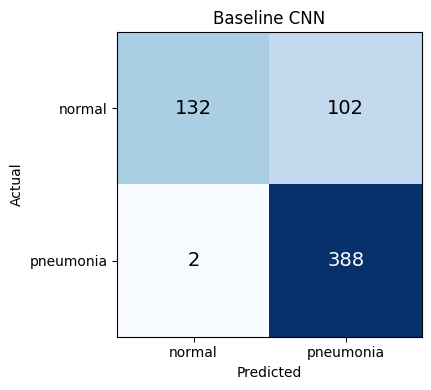

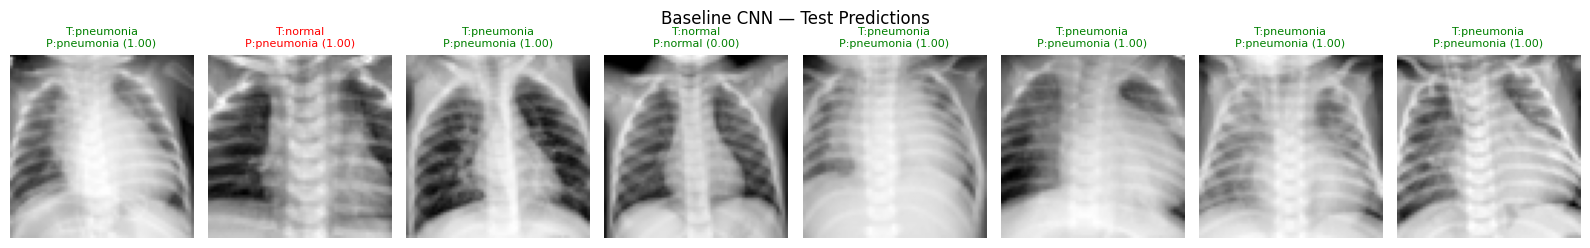

In [ ]:
# ==============================================================
# Task 2.3: Evaluate and visualize baseline predictions [2 pts]
# ==============================================================

# TODO: evaluate the baseline model on the unchanged test set using evaluate_model()
# TODO: use that baseline_metrics to plot the confusion matrix with plot_confusion_matrix()
# TODO: visualize a few baseline prediction examples using plot_prediction_examples()
baseline_metrics = evaluate_model(baseline_model, test_images, test_labels, "Baseline CNN")
plot_confusion_matrix(np.array(baseline_metrics["confusion_matrix"]), "Baseline CNN")
plot_prediction_examples(baseline_model, test_images, test_labels, n=8, title="Baseline CNN — Test Predictions")

## Part 3 — Traditional Augmentation CNN with Checkpoint Loading and Fine-Tuning [10 pts]

In this part, you will train a second CNN using standard traditional image augmentation that applies small label-preserving transformations during training, such as rotation, translation, zoom, and contrast changes.

**Task (10 pts total):**
- **3.1 Define the traditional augmentation pipeline [3 pts]**
- **3.2 Visualize augmented pneumonia samples [2 pts]**
- **3.3 Load the checkpoint and fine-tune the traditional-augmentation CNN [3 pts]**
- **3.4 Evaluate the traditional-augmentation model [2 pts]**

This part tests whether standard image transformations help the imbalanced classifier generalize better.

### 3.1 Define the Traditional Augmentation Pipeline [3 pts]

In this section, you will create a Keras augmentation pipeline for chest X-ray images. The goal is to make the classifier less sensitive to small changes in image position, scale, and contrast.

The transformations should be mild because medical images should not be distorted too aggressively. The image should still look like a valid chest X-ray after augmentation.

**Task (3 pts):** Build the traditional augmentation pipeline.

The code should:

- create a `keras.Sequential` augmentation model
- include random rotation, translation, zoom, and contrast layers
- use the provided global augmentation constants
- use `fill_mode=TRAD_FILL_MODE` for the rotation, translation, and zoom layers to avoid unrealistic border artifacts

Expected output: the augmentation configuration printed from the notebook.

In [ ]:
# ==============================================================
# Task 3.1: Define the traditional augmentation pipeline [3 pts]
# ==============================================================

# TODO: build a Keras Sequential augmentation pipeline
# TODO: include small random rotation, translation, zoom, and contrast changes
# TODO: use the provided global augmentation constants TRAD_ROTATION_FACTOR, TRAD_TRANSLATION_FACTOR, TRAD_ZOOM_FACTOR, TRAD_CONTRAST_FACTOR, TRAD_FILL_MODE, SEED
# TODO: use fill_mode=TRAD_FILL_MODE for rotation, translation, and zoom
aug_pipeline = keras.Sequential([
    layers.RandomRotation(TRAD_ROTATION_FACTOR, fill_mode=TRAD_FILL_MODE, seed=SEED),
    layers.RandomTranslation(
        TRAD_TRANSLATION_FACTOR,
        TRAD_TRANSLATION_FACTOR,
        fill_mode=TRAD_FILL_MODE,
        seed=SEED,
    ),
    layers.RandomZoom(TRAD_ZOOM_FACTOR, fill_mode=TRAD_FILL_MODE, seed=SEED),
    layers.RandomContrast(TRAD_CONTRAST_FACTOR, seed=SEED),
], name="traditional_augmentation")

print("Traditional augmentation config:")
print(f"  rotation factor:    {TRAD_ROTATION_FACTOR}")
print(f"  translation factor: {TRAD_TRANSLATION_FACTOR}")
print(f"  zoom factor:        {TRAD_ZOOM_FACTOR}")
print(f"  contrast factor:    {TRAD_CONTRAST_FACTOR}")
print(f"  fill mode:          {TRAD_FILL_MODE}")

Traditional augmentation config:
  rotation factor:    0.025
  translation factor: 0.04
  zoom factor:        0.05
  contrast factor:    0.1
  fill mode:          nearest


### 3.2 Visualize Traditional Augmentation Examples [2 pts]

Before using augmentation for training, it is important to visually inspect the transformed images. This helps confirm that the augmentations are reasonable and still preserve the pneumonia label.

**Task (2 pts):** Visualize augmented minority-class samples.

The code should:

- select a few pneumonia images from the imbalanced training set
- use the visualization helper to apply the augmentation pipeline with `training=True`
- display the original and augmented versions side by side

Expected output: a grid showing original images and their augmented versions.

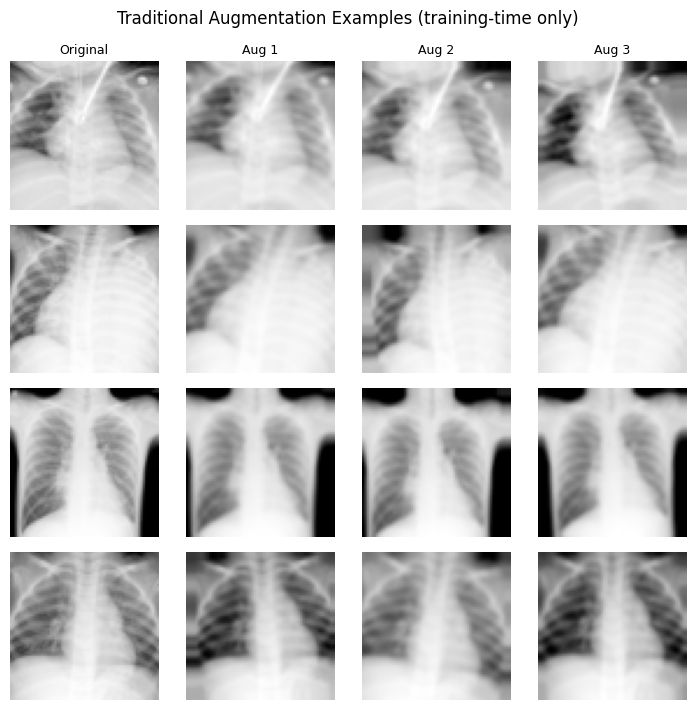

In [ ]:
# =============================================================
# Task 3.2: Visualize traditional augmentation examples [2 pts]
# =============================================================

# TODO: select a few minority-class training images
# TODO: use the visualization helper plot_traditional_aug_examples() to apply aug_pipeline with training=True
# TODO: display the original and augmented versions side by side
minority_mask_vis = imb_train_labels == MINORITY_CLASS
minority_vis = imb_train_images[minority_mask_vis][:4]
plot_traditional_aug_examples(minority_vis, aug_pipeline, n=4, repeats=3)

### 3.3 Load the Traditional-Augmentation Checkpoint and Fine-Tune [3 pts]

In this section, you will load the provided traditional-augmentation CNN `.keras` checkpoint and fine-tune it using augmented training batches.

The augmentation is applied only inside the training dataset through `aug_pipeline`. Validation and test examples are not augmented.

**Task (3 pts):** Fine-tune the traditional-augmentation model.

The code should:

- reset random seeds for reproducibility
- validate and load the full saved traditional-augmentation `.keras` model
- compile the loaded model for gentle fine-tuning using the provided helper function
- create a training dataset that applies `aug_pipeline`
- fine-tune the model using augmented training batches

Expected output: training and validation loss/accuracy for the traditional augmentation model.

In [ ]:
# ========================================================================
# Task 3.3: Load traditional-augmentation checkpoint and fine-tune [3 pts]
# ========================================================================

# TODO: reset random seeds before fine-tuning
# TODO: validate and load the full saved traditional-augmentation .keras model
# TODO: compile the loaded model for gentle fine-tuning using compile_classifier_for_key_finetune()
reset_all_seeds(SEED + 2000)
validate_checkpoint(TRAD_AUG_PRETRAINED_PATH)
trad_aug_model = keras.saving.load_model(TRAD_AUG_PRETRAINED_PATH)
trad_aug_model = compile_classifier_for_key_finetune(trad_aug_model)

# TODO: create a training dataset that applies aug_pipeline during training
# TODO: use the unchanged validation dataset and fine-tune the model using augmented training batches
aug_train_ds = make_tf_dataset(imb_train_images, imb_train_labels, augment_fn=aug_pipeline)
trad_aug_history = trad_aug_model.fit(
    aug_train_ds,
    validation_data=val_ds,
    epochs=KEY_FINE_TUNE_EPOCHS,
    verbose=1,
)


  ✓ Loaded checkpoints/traditional_aug_cnn_final.keras
  ✓ Validated checkpoints/traditional_aug_cnn_final.keras
Epoch 1/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.8938 - loss: 0.2526 - val_accuracy: 0.7882 - val_loss: 0.4569
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9079 - loss: 0.2204 - val_accuracy: 0.8187 - val_loss: 0.3803
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9200 - loss: 0.1957 - val_accuracy: 0.8473 - val_loss: 0.3250
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9315 - loss: 0.1688 - val_accuracy: 0.8664 - val_loss: 0.2875
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9351 - loss: 0.1606 - val_accuracy: 0.8836 - val_loss: 0.2617


### 3.4 Evaluate the Traditional-Augmentation Model [2 pts]

After fine-tuning, evaluate the model on the same unchanged test set used for the baseline model. This shows whether standard augmentation improves performance under class imbalance.

**Task (2 pts):** Evaluate the traditional-augmentation model that will:
- compute traditional-augmentation test metrics using `evaluate_model``
- plot the confusion matrix

Expected output: traditional-augmentation test metrics, classification report, and confusion matrix.



  Traditional Aug CNN — Test Evaluation
  Accuracy: 0.8269  Macro-F1: 0.8067
  Minority Precision: 0.8234  Minority Recall: 0.9205
              precision    recall  f1-score   support

      normal       0.84      0.67      0.74       234
   pneumonia       0.82      0.92      0.87       390

    accuracy                           0.83       624
   macro avg       0.83      0.80      0.81       624
weighted avg       0.83      0.83      0.82       624



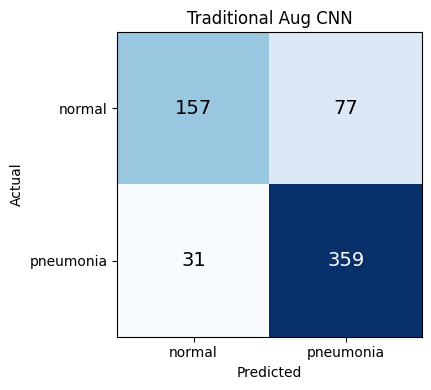

In [ ]:
# =============================================================
# Task 3.4: Evaluate the traditional-augmentation model [2 pts]
# =============================================================

# TODO: evaluate the traditional-augmentation model on the unchanged test set using evaluate_model()
# TODO: plot the confusion matrix from trad_aug_metrics using plot_confusion_matrix()
trad_aug_metrics = evaluate_model(trad_aug_model, test_images, test_labels, "Traditional Aug CNN")
plot_confusion_matrix(np.array(trad_aug_metrics["confusion_matrix"]), "Traditional Aug CNN")

## Part 4 — Diffusion-Style Masked Denoising/Inpainting Augmentation [50 pts]

The denoiser checkpoint is loaded from the provided `denoiser_final.keras` file. The denoiser is fine-tuned briefly on the imbalanced training-set pneumonia samples, then used to generate additional minority-class training images.

**Task (50 pts total):**

- **4.1 Define the diffusion noise schedule [5 pts]**
- **4.2 Implement one reverse diffusion sampling step [5 pts]**
- **4.3 Implement masked diffusion inpainting [10 pts]**
- **4.4 Fine-tune the pretrained diffusion denoiser [10 pts]**
- **4.5 Generate synthetic minority-class samples [10 pts]**
- **4.6 Fine-tune and evaluate the diffusion-augmented CNN [10 pts]**

Generated images must never be added to the validation or test set.

### 4.1 Defining the Diffusion Noise Schedule [5 pts]

In diffusion models, the noise schedule controls how much noise is gradually added to an image during the forward diffusion process. In this section, you will construct the sequence of noise parameters used throughout the diffusion timesteps.

We first create a linearly spaced sequence of noise values called `betas` using `np.linspace`. The schedule begins at `NOISE_BETA_START` and increases to `NOISE_BETA_END` over `DIFFUSION_TIMESTEPS` steps.

Next, we compute the corresponding `alphas` values using the relationship:

$\alpha_t = 1 - \beta_t$

We then calculate the cumulative product of the alphas across timesteps, commonly denoted as $\bar{\alpha}_t$. These cumulative values are important because they determine how much of the original image signal remains after repeated noise addition.

Finally, we convert the NumPy arrays into TensorFlow constants so they can be efficiently used during model training and sampling.

**Task (5 pts):** Create the diffusion schedule that:
- create a linear `betas` schedule from `NOISE_BETA_START` to `NOISE_BETA_END`
- compute `alphas = 1 - betas`
- compute cumulative products `alpha_bars`
- convert the arrays into TensorFlow constants

In [ ]:
# ── Diffusion schedule ──

# TODO: create a linear beta schedule
# TODO: compute alpha values
# TODO: compute cumulative products of alphas
# TODO: convert arrays to TensorFlow constants
betas_np = np.linspace(NOISE_BETA_START, NOISE_BETA_END, DIFFUSION_TIMESTEPS, dtype=np.float32)
alphas_np = 1.0 - betas_np
alpha_bars_np = np.cumprod(alphas_np).astype(np.float32)
BETAS = tf.constant(betas_np)
ALPHAS = tf.constant(alphas_np)
ALPHA_BARS = tf.constant(alpha_bars_np)

### 4.2 Reverse Diffusion Step (Sampling) [5 pts]

In this section, you will implement a single **reverse diffusion step**, which is the core operation used during image generation in a diffusion model.

During training, the model learns to predict the noise added to an image at a given timestep. During sampling, we use these predictions to gradually denoise a noisy image, step by step, starting from pure noise.

At each timestep `t`, the model takes the current noisy image `x_t` and the timestep embedding as input, and predicts the noise component. We then use the DDPM reverse process equations to compute the mean of the previous timestep distribution.

If `t > 0`, we also add random Gaussian noise to maintain stochasticity in the sampling process. For the final timestep, we return only the computed mean without additional noise.

**Task (5 pts):** Complete `reverse_step(...)` where the function should:
- create a batch of timestep values
- predict the noise using the denoiser
- gather the correct diffusion constants for timestep `t`
- compute the reverse-process mean
- add Gaussian noise when `t > 0`
- return the final mean directly when `t == 0`

In [ ]:
def reverse_step(model, x_t, t):
    # TODO: get batch size
    # TODO: create a batch of timestep values
    # TODO: predict noise using the model
    # TODO: extract diffusion schedule values at timestep t
    # TODO: compute the mean of the reverse process
    # TODO: add noise if not at final timestep

    n = tf.shape(x_t)[0]
    t_batch = tf.fill([n], t)
    pred_noise = model([x_t, t_batch], training=False)
    alpha = ALPHAS[t]
    alpha_bar = ALPHA_BARS[t]
    beta = BETAS[t]
    mean = (1.0 / tf.sqrt(alpha)) * (x_t - (beta / tf.sqrt(1.0 - alpha_bar)) * pred_noise)
    if t > 0:
        return mean + tf.sqrt(beta) * tf.random.normal(tf.shape(x_t))
    return mean

### 4.3 Image Inpainting with a Diffusion Model [10 pts]

In this section, you will implement an **inpainting procedure** using a trained diffusion model. Inpainting is the task of reconstructing missing or masked regions of an image while preserving the visible context.

The function takes a set of source images and generates new inpainted versions by repeatedly running the reverse diffusion process while enforcing known pixels from the original image.

For each input image, we first ensure it has the correct shape and create a random rectangular mask. This mask represents the region of the image that will be regenerated by the model. The rest of the image remains fixed and is used as conditioning information.

We then initialize a noisy image and iteratively apply the reverse diffusion step from the final timestep to timestep 0. At each step, we combine the model’s prediction with the known (unmasked) regions from the original image using the mask.

At intermediate timesteps, we add noise-consistent versions of the source image using the forward diffusion process (`q_sample`). At the final timestep, we directly paste the original image content into the unmasked region to ensure consistency.

The result is a set of images where only the masked region has been generated by the diffusion model, while the rest remains faithful to the original input.

**Task (10 pts):** Complete `generate_inpainted_samples(...)` where the function should:
- create a random rectangular mask
- start generation from random noise
- run reverse diffusion from the final timestep to timestep `0`
- regenerate only the masked region
- preserve the unmasked region from the original image
- return clipped images in the range `[0, 1]`

In [ ]:
def generate_inpainted_samples(model, source_images, n_per_image=1, mask_frac=INPAINT_MASK_FRAC):
    results = []
    for src in source_images:
        # TODO: convert source image to float32 tensor
        # TODO: ensure channel dimension exists
        src = tf.cast(src, tf.float32)
        if len(src.shape) == 2:
            # TODO: define image dimensions
            src = src[..., tf.newaxis]
        for _ in range(n_per_image):
            # TODO: compute mask height and width
            # TODO: randomly sample mask top-left corner
            # TODO: create empty mask
            # TODO: fill masked region with 1s
            # TODO: convert mask to tensor
            # TODO: initialize noise image
            # TODO: add batch dimension to source image
            # reverse diffusion loop
            h = w = IMG_SIZE
            mh = int(h * mask_frac)
            mw = int(w * mask_frac)
            top = np.random.randint(0, h - mh + 1)
            left = np.random.randint(0, w - mw + 1)
            mask = np.zeros((h, w, 1), dtype=np.float32)
            mask[top:top + mh, left:left + mw, :] = 1.0
            mask_tf = tf.constant(mask)
            x = tf.random.normal((1, IMG_SIZE, IMG_SIZE, 1))
            src_b = src[tf.newaxis]
            for t in reversed(range(DIFFUSION_TIMESTEPS)):
                # TODO: apply reverse diffusion step
                x = reverse_step(model, x, t)
                if t > 0:
                    # TODO: apply forward noising to source image
                    # TODO: combine generated and source regions using mask
                    noised_src = q_sample(src_b, tf.constant([t]))
                    x = mask_tf * x + (1.0 - mask_tf) * noised_src
                else:
                    # TODO: final step: directly enforce known pixels
                    x = mask_tf * x + (1.0 - mask_tf) * src_b
            # TODO: clip output to valid pixel range
            results.append(tf.clip_by_value(x[0], 0.0, 1.0))
    return tf.stack(results)

## Diffusion Helpers (Provided)

### Forward Diffusion Sampling

In this section, you will implement the forward diffusion process used in DDPMs. The function `q_sample` adds Gaussian noise to an image at a given timestep $t$.

First, we sample random noise if none is provided. We then retrieve the cumulative diffusion coefficient $\bar{\alpha}_t$ and reshape it for broadcasting.

Finally, we generate the noisy image using:

$\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t}\boldsymbol{\epsilon}$

where:
- $\mathbf{x}_0$ is the original image,
- and $\boldsymbol{\epsilon}$ is Gaussian noise.

In [ ]:
def q_sample(x0, t, noise=None):
    if noise is None:
        noise = tf.random.normal(tf.shape(x0))
    ab = tf.gather(ALPHA_BARS, t)
    while len(ab.shape) < len(x0.shape):
        ab = ab[..., tf.newaxis]
    return tf.sqrt(ab) * x0 + tf.sqrt(1.0 - ab) * noise

### Sinusoidal Time Embeddings

This layer converts diffusion timesteps into continuous vector representations using sine and cosine functions at different frequencies. These embeddings provide the model with information about the current diffusion timestep during training and sampling.

Sinusoidal embeddings are commonly used in diffusion models and transformer architectures because they encode timestep information in a smooth and structured way.

In [ ]:
@keras.saving.register_keras_serializable(package="DiffusionInpainting")
class SinusoidalTimeEmbedding(layers.Layer):
    def __init__(self, dim=64, **kwargs):
        super().__init__(**kwargs)
        self.dim = dim

    def call(self, t):
        half = self.dim // 2
        freqs = tf.exp(-tf.math.log(10000.0) * tf.range(half, dtype=tf.float32) / half)
        t_f = tf.cast(tf.reshape(t, [-1]), tf.float32)
        args = t_f[:, tf.newaxis] * freqs[tf.newaxis, :]
        return tf.concat([tf.sin(args), tf.cos(args)], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({"dim": self.dim})
        return config

### Inpainting with a Fixed Mask

In this section, you will implement diffusion-based image inpainting using a predefined binary mask.

The mask controls which pixels are regenerated:
- `mask = 1` → generate new content
- `mask = 0` → preserve the original image

Starting from random noise, the model iteratively applies the reverse diffusion process while keeping the unmasked regions consistent with the source image. The final output is clipped to the valid pixel range $[0,1]$.

In [ ]:
def generate_inpainted_with_fixed_mask(model, source_image, mask):
    """Generate one inpainted image using a provided binary mask.
    mask = 1 inside the region to generate; mask = 0 outside the region to preserve.
    """
    src = tf.cast(source_image, tf.float32)
    if len(src.shape) == 2:
        src = src[..., tf.newaxis]
    src_b = src[tf.newaxis]
    mask_tf = tf.constant(mask.astype(np.float32))
    x = tf.random.normal((1, IMG_SIZE, IMG_SIZE, 1))
    for t in reversed(range(DIFFUSION_TIMESTEPS)):
        x = reverse_step(model, x, t)
        if t > 0:
            anchor_noise = tf.random.normal(tf.shape(src_b))
            noised_src = q_sample(src_b, tf.constant([t]), anchor_noise)
            x = mask_tf * x + (1.0 - mask_tf) * noised_src
        else:
            x = mask_tf * x + (1.0 - mask_tf) * src_b
    return tf.clip_by_value(x[0], 0.0, 1.0)

### Creating a Soft Visualization Mask

This function creates a softly blended version of a binary mask for visualization purposes. It applies average pooling multiple times to blur the mask edges, producing smoother transitions between masked and unmasked regions.

In [ ]:
def make_soft_mask(mask, blur_size=5):
    """Create a softly blended version of a binary mask for visualization only."""
    mask_tf = tf.convert_to_tensor(mask[tf.newaxis], dtype=tf.float32)
    for _ in range(2):
        mask_tf = tf.nn.avg_pool2d(mask_tf, ksize=blur_size, strides=1, padding="SAME")
    return tf.clip_by_value(mask_tf[0], 0.0, 1.0).numpy()

In [ ]:
def plot_diffusion_inpainting_examples(denoiser, source_images, n=4, mask_frac=INPAINT_MASK_FRAC):
    """Visualize original → same mask → inpainted output.
    A soft mask is used only for display so the generated patch blends more smoothly.
    """
    n = min(n, len(source_images))
    fig, axes = plt.subplots(n, 3, figsize=(6, n * 2))
    if n == 1:
        axes = axes[np.newaxis, :]
    for i in range(n):
        src = source_images[i]
        src_2d = np.squeeze(src)
        h = w = IMG_SIZE
        mh = int(h * mask_frac)
        mw = int(w * mask_frac)
        top = np.random.randint(0, h - mh + 1)
        left = np.random.randint(0, w - mw + 1)
        mask = np.zeros((h, w, 1), dtype=np.float32)
        mask[top:top + mh, left:left + mw, :] = 1.0
        masked_vis = src_2d.copy()
        masked_vis[top:top + mh, left:left + mw] = 0.5

        raw_inpainted = generate_inpainted_with_fixed_mask(denoiser, src, mask)
        soft_mask = make_soft_mask(mask)
        display_inpainted = soft_mask * raw_inpainted.numpy() + (1.0 - soft_mask) * src
        display_inpainted = np.clip(display_inpainted, 0.0, 1.0)

        axes[i, 0].imshow(src_2d, cmap="gray")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(masked_vis, cmap="gray")
        axes[i, 1].axis("off")
        axes[i, 2].imshow(np.squeeze(display_inpainted), cmap="gray")
        axes[i, 2].axis("off")
    axes[0, 0].set_title("Original", fontsize=9)
    axes[0, 1].set_title("Same Mask Used\nfor Inpainting", fontsize=9)
    axes[0, 2].set_title("Inpainted Output", fontsize=9)
    fig.suptitle("Diffusion Inpainting: Original → Same Mask → Inpainted")
    plt.tight_layout()
    plt.show()


print("Diffusion helpers loaded.")

Diffusion helpers loaded.


### 4.4 Fine-tuning a Pretrained Diffusion Denoiser [10 pts]

In this section, you will load a pretrained diffusion denoiser and fine-tune it briefly on the **minority class** of the imbalanced dataset. This step helps the model better adapt to underrepresented data and improves generation quality for that class.

We begin by resetting random seeds for reproducibility and validating that the pretrained checkpoint exists and is compatible with a denoiser model. The model is then loaded using Keras and compiled with an Adam optimizer and mean squared error (MSE) loss, which is standard for predicting noise in diffusion models.

Next, we filter the imbalanced training dataset to retain only samples from the minority class. This subset is used exclusively for fine-tuning.

During training, we iterate over the minority dataset in mini-batches. For each batch, we randomly sample diffusion timesteps and generate Gaussian noise. We then apply the forward diffusion process (`q_sample`) to produce noisy inputs, and train the model to predict the original noise added to the images.

The loss is computed using `train_on_batch`, and we track the average loss across each epoch to monitor convergence during fine-tuning.

**Task (10 pts):** Fine-tune the denoiser on pneumonia samples from the imbalanced training set, the training loop should:
- validate and load the pretrained denoiser checkpoint
- compile the denoiser with Adam and MSE loss
- select only minority-class pneumonia images
- sample random diffusion timesteps
- add Gaussian noise using `q_sample(...)`
- train the denoiser to predict the added noise
- print the average loss for each epoch

In [ ]:
# ==========================================================
# Solution 4.4: Load pretrained denoiser and fine-tune briefly [10 pts]
# ==========================================================
# TODO: reset random seeds for reproducibility
# TODO: validate pretrained checkpoint
# TODO: load pretrained denoiser model
# TODO: compile model with Adam optimizer and MSE loss
# TODO: create minority class mask
# TODO: extract minority class images
# TODO: loop over epochs

reset_all_seeds(SEED + 2500)
validate_checkpoint(DENOISER_PRETRAINED_PATH, is_denoiser=True)
denoiser = keras.saving.load_model(DENOISER_PRETRAINED_PATH)
denoiser.compile(optimizer=keras.optimizers.Adam(KEY_DENOISER_LR), loss="mse")

minority_mask = imb_train_labels == MINORITY_CLASS
minority_images = imb_train_images[minority_mask]
print(f"Fine-tuning denoiser on {len(minority_images)} minority samples")

for ep in range(KEY_FINE_TUNE_EPOCHS):
    # TODO: extract batch
    # TODO: sample random timesteps
    # TODO: sample Gaussian noise
    # TODO: apply forward diffusion process
    # TODO: train denoiser to predict noise
    losses = []
    idx = np.arange(len(minority_images))
    np.random.shuffle(idx)
    for s in range(0, len(minority_images), BATCH_SIZE):
        batch = tf.constant(minority_images[idx[s:s + BATCH_SIZE]])
        t = tf.random.uniform([len(batch)], 0, DIFFUSION_TIMESTEPS, dtype=tf.int32)
        noise = tf.random.normal(tf.shape(batch))
        noisy = q_sample(batch, t, noise)
        loss = denoiser.train_on_batch([noisy, t], noise)
        losses.append(float(np.asarray(loss).item()))
    print(f"  Epoch {ep + 1}/{KEY_FINE_TUNE_EPOCHS} — loss: {np.mean(losses):.6f}")


  ✓ Loaded checkpoints/denoiser_final.keras
  ✓ Validated checkpoints/denoiser_final.keras
Fine-tuning denoiser on 698 minority samples
  Epoch 1/5 — loss: 0.026421
  Epoch 2/5 — loss: 0.025649
  Epoch 3/5 — loss: 0.025919
  Epoch 4/5 — loss: 0.025131
  Epoch 5/5 — loss: 0.025253


The same mask is used for the masked panel and the inpainted output, so the visualization accurately shows what region was generated.

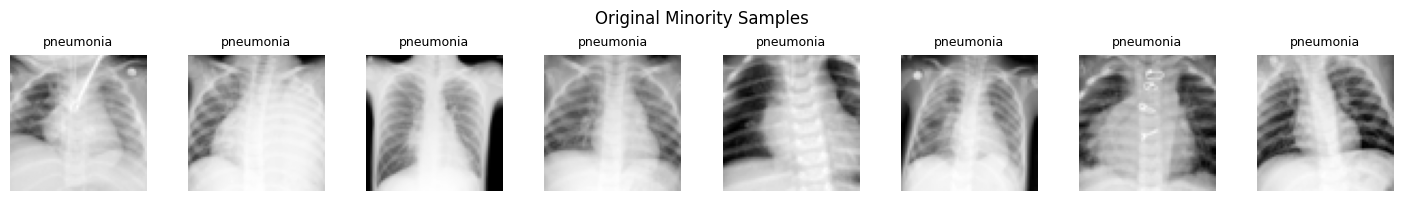

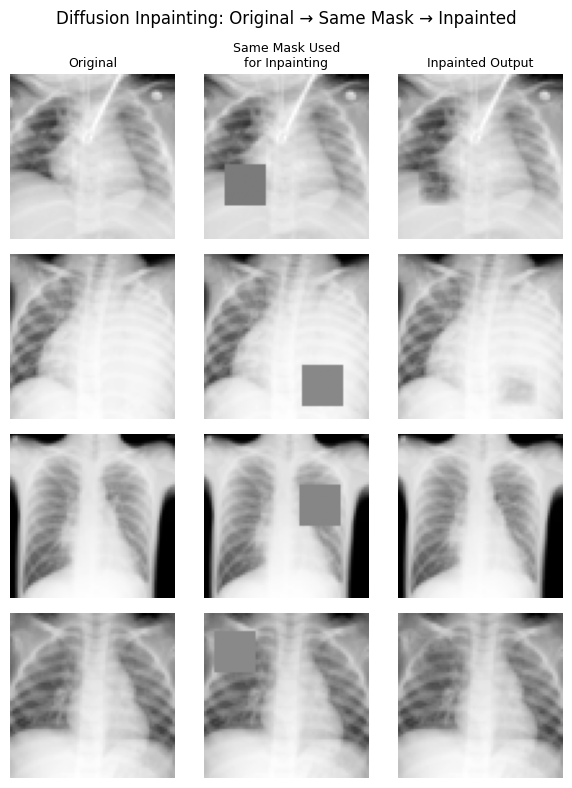

In [ ]:
plot_original_samples(minority_images, np.full(len(minority_images[:8]), MINORITY_CLASS, dtype=np.int32),
                      n=8, title="Original Minority Samples")
plot_diffusion_inpainting_examples(denoiser, minority_images[:4], n=4, mask_frac=INPAINT_MASK_FRAC)

### 4.5 Generate synthetic minority-class samples [10 pts]

**Task (10 pts):**
  - load the denoiser checkpoint
  - train it to predict noise on pneumonia samples
  - report the average loss per epoch

In this section, you will generate additional minority-class samples using the diffusion inpainting model. The goal is to reduce class imbalance by creating synthetic training examples.

First, compute the current number of minority-class samples and determine the target number of samples using `TARGET_MINORITY_MULTIPLIER`. From this, calculate how many new images need to be generated.

If additional samples are required, randomly select seed images from the existing minority dataset and pass them through the inpainting generation pipeline. The generated images are then assigned the minority-class label.

If no additional samples are needed, create empty placeholder arrays for the generated images and labels.

Finally, visualize several generated samples to inspect the quality of the synthetic images.

**Note: This task may take a while to generate 698 samples (~ 1hour). Feel free to generate that much. If not, you can set n_to_generate to a lower number like 8, then you can use the provided generated_images and generated_labels numpy files to load them for the next steps.**

Current minority: 698, target: 1396, generating: 698
Generated 698 samples, shape: (698, 64, 64, 1)


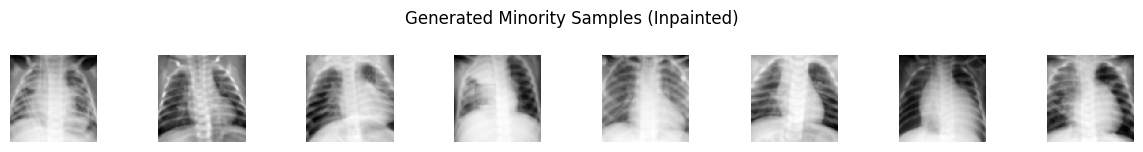

In [ ]:
# ==========================================================
# Solution 4.5: Generate synthetic minority samples [10 pts]
# ==========================================================

# TODO: count the current number of minority-class samples
# TODO: compute the target number of minority samples
# TODO: determine how many new samples must be generated
# TODO: generate synthetic samples only if needed
n_minority_current = int(np.sum(imb_train_labels == MINORITY_CLASS))
n_target = n_minority_current * TARGET_MINORITY_MULTIPLIER
n_to_generate = max(0, n_target - n_minority_current)
print(f"Current minority: {n_minority_current}, target: {n_target}, generating: {n_to_generate}")

if n_to_generate > 0:
    # TODO: randomly select seed image indices
    # TODO: generate synthetic images using generate_inpainted_samples()
    # TODO: create labels for generated images
    seed_idx = np.random.choice(len(minority_images), n_to_generate, replace=True)
    seed_imgs = minority_images[seed_idx]
    generated_images = generate_inpainted_samples(
        denoiser,
        seed_imgs,
        n_per_image=1,
        mask_frac=INPAINT_MASK_FRAC,
    ).numpy()
    generated_labels = np.full(len(generated_images), MINORITY_CLASS, dtype=np.int32)
else:
    generated_images = np.empty((0, IMG_SIZE, IMG_SIZE, 1), dtype=np.float32)
    generated_labels = np.array([], dtype=np.int32)

print(f"Generated {len(generated_images)} samples, shape: {generated_images.shape}")
plot_image_grid(generated_images, n=8, title="Generated Minority Samples (Inpainted)")


### Optional
Run this code only if you only generated fewer images in the last step

In [ ]:
generated_images = np.load("checkpoints/generated_images.npy")
generated_labels = np.load("checkpoints/generated_labels.npy")

### 4.6 Fine-Tune and Evaluate the Diffusion-Augmented CNN [10 pts]
  - use the fine-tuned denoiser for inpainting
  - generate additional pneumonia samples
  - save and visualize generated images

In this section, you will combine the original imbalanced dataset with the generated minority-class samples to create a diffusion-augmented training set.

After merging the datasets, we shuffle the combined images and labels and inspect the updated class distribution.

Next, we load a pretrained CNN classifier and fine-tune it on the augmented dataset. The model is trained using TensorFlow datasets created with `make_tf_dataset`.

Finally, we evaluate the fine-tuned model on the test set and visualize its confusion matrix to analyze classification performance.

Diffusion-augmented train set: 2610 samples
Class counts: [1214 1396]
  ✓ Loaded checkpoints/diffusion_aug_cnn_final.keras
  ✓ Validated checkpoints/diffusion_aug_cnn_final.keras
Epoch 1/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9714 - val_loss: 0.1037
Epoch 2/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9695 - val_loss: 0.1070
Epoch 3/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9714 - val_loss: 0.1062
Epoch 4/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9714 - val_loss: 0.1084
Epoch 5/5
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 9.6766e-04 - val_accuracy: 0.9695 - val_loss: 0.1092



  Diffusion Aug CNN — Test Evaluation
  Accuracy: 0.9135  Macro-F1: 0.9033
  Minority Precision: 0.8853  Minority Recall: 0.9897
              precision    recall  f1-score   support

      normal       0.98      0.79      0.87       234
   pneumonia       0.89      0.99      0.93       390

    accuracy                           0.91       624
   macro avg       0.93      0.89      0.90       624
weighted avg       0.92      0.91      0.91       624



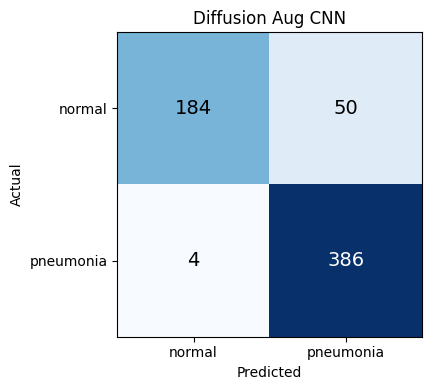

In [ ]:
# ==========================================================
# Solution 4.6: Load pretrained diffusion-augmented CNN and fine-tune [10 pts]
# ==========================================================

# TODO: combine original and generated training images
# TODO: combine original and generated labels
# TODO: shuffle the combined dataset


diff_train_images = np.concatenate([imb_train_images, generated_images], axis=0).astype(np.float32)
diff_train_labels = np.concatenate([imb_train_labels, generated_labels], axis=0).astype(np.int32)
perm = np.random.permutation(len(diff_train_images))
diff_train_images, diff_train_labels = diff_train_images[perm], diff_train_labels[perm]
print(f"Diffusion-augmented train set: {len(diff_train_images)} samples")
print("Class counts:", np.bincount(diff_train_labels, minlength=2))

# TODO: reset random seeds
# TODO: validate pretrained classifier checkpoint
# TODO: load pretrained CNN model
# TODO: compile model for fine-tuning
reset_all_seeds(SEED + 3000)
validate_checkpoint(DIFFUSION_AUG_PRETRAINED_PATH)
diff_aug_model = keras.saving.load_model(DIFFUSION_AUG_PRETRAINED_PATH)
diff_aug_model = compile_classifier_for_key_finetune(diff_aug_model)

# TODO: create TensorFlow training dataset
# TODO: fine-tune the classifier
diff_train_ds = make_tf_dataset(diff_train_images, diff_train_labels)
diff_aug_history = diff_aug_model.fit(
    diff_train_ds,
    validation_data=val_ds,
    epochs=KEY_FINE_TUNE_EPOCHS,
    verbose=1,
)

# TODO: evaluate the fine-tuned model
diff_aug_metrics = evaluate_model(diff_aug_model, test_images, test_labels, "Diffusion Aug CNN")
plot_confusion_matrix(np.array(diff_aug_metrics["confusion_matrix"]), "Diffusion Aug CNN")


## Part 5 — Metrics and Model Comparison [15 pts]

The table below reports metrics computed in this Key notebook run after brief fine-tuning. These are the values that should be discussed for this run.

### 5.1 Model Comparison [5 pts]
> Based on the metrics below, compare the performances of baseline, traditional augmentation, and diffusion-augmented CNN.

**Model Comparison Answer**

> Based on the comparison table, the **Diffusion Aug CNN** performs best overall. It has the highest accuracy (**0.9135**) and the highest macro-F1 score (**0.9033**), showing stronger balanced performance across the normal and pneumonia classes.

> The baseline model has very high pneumonia recall (**0.9949**), but its macro-F1 score is lower (**0.7996**) because it performs worse on the normal class. Traditional augmentation slightly improves macro-F1 compared with the baseline (**0.8067** vs. **0.7996**), but its pneumonia recall drops to **0.9205**. The diffusion-augmented model gives the best tradeoff because it keeps pneumonia recall high (**0.9897**) while also improving minority precision (**0.8853**) and overall macro-F1.


In [ ]:
# ==========================================================
# Solution 5.1: Comparison table [5 pts]
# ==========================================================
all_metrics = {
    "Baseline CNN": baseline_metrics,
    "Traditional Aug CNN": trad_aug_metrics,
    "Diffusion Aug CNN": diff_aug_metrics,
}

print("Metrics from this Key notebook run after fine-tuning:")
print(f"{'Model':<25} {'Acc':>8} {'F1':>8} {'Prec':>8} {'Rec':>8}")
print("-" * 57)
for nm, m in all_metrics.items():
    print(
        f"{nm:<25} {m['accuracy']:>8.4f} {m['macro_f1']:>8.4f} "
        f"{m['minority_precision']:>8.4f} {m['minority_recall']:>8.4f}"
    )


Metrics from this Key notebook run after fine-tuning:
Model                          Acc       F1     Prec      Rec
---------------------------------------------------------
Baseline CNN                0.8333   0.7996   0.7918   0.9949
Traditional Aug CNN         0.8269   0.8067   0.8234   0.9205
Diffusion Aug CNN           0.9135   0.9033   0.8853   0.9897


### 5.2 Confusion Matrix [3 pts]
> What improvements do you see for the traditional and diffusion augmentation over the baseline CNN model?

**Confusion Matrix Answer**

> Yes, the **Diffusion Aug CNN** is more balanced across classes than the baseline and traditional augmentation models. The baseline model has excellent pneumonia recall, but normal-class recall is only **0.56**, meaning many normal images are incorrectly predicted as pneumonia. Traditional augmentation improves normal recall to **0.67**, but pneumonia recall decreases to **0.92**.

> The diffusion-augmented model improves normal recall to **0.79** while keeping pneumonia recall high at **0.99**. It also has the highest macro-F1 score (**0.90**), so it is the most balanced model in this run. However, it is not perfectly balanced because pneumonia performance is still stronger than normal-class performance.

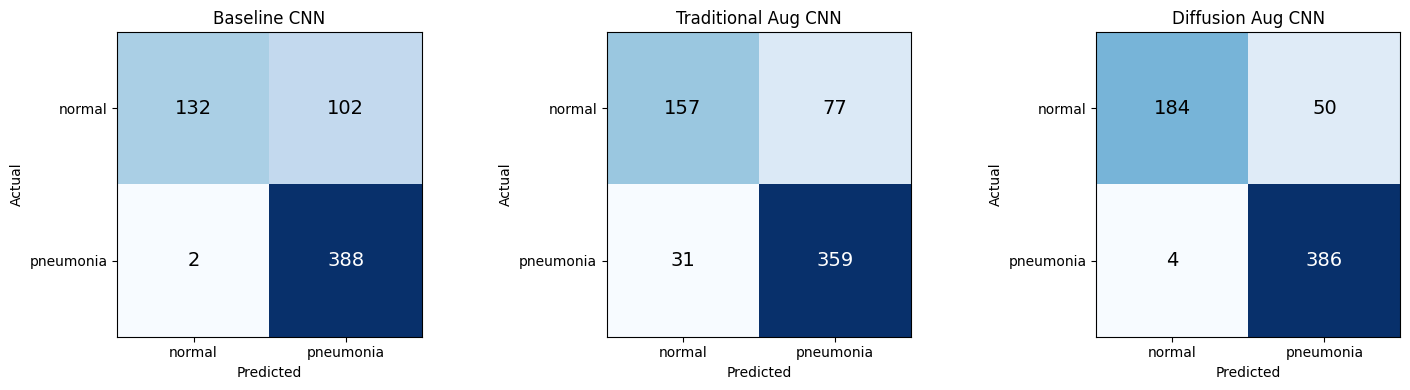

In [ ]:
# ==========================================================
# Solution 5.2: Side-by-side confusion matrices [3 pts]
# ==========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nm, m) in zip(axes, all_metrics.items()):
    cm = np.array(m["confusion_matrix"])
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["normal","pneumonia"]); ax.set_yticklabels(["normal","pneumonia"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(nm)
    for i in range(2):
        for j in range(2):
            ax.text(j,i,str(cm[i][j]),ha="center",va="center",
                    color="white" if cm[i][j]>cm.max()/2 else "black", fontsize=14)
plt.tight_layout(); plt.show()

### 5.3 Classfication Reports [5 pts]

> Looking at precision and recall for both classes, do you think the diffusion model is “fairer” across classes?

**Classification Reports Answer**

> Yes, the **Diffusion Aug CNN** is more balanced across classes than the baseline and traditional augmentation models. The baseline model has excellent pneumonia recall, but normal-class recall is only **0.56**, meaning many normal images are incorrectly predicted as pneumonia. Traditional augmentation improves normal recall to **0.67**, but pneumonia recall decreases to **0.92**.

> The diffusion-augmented model improves normal recall to **0.79** while keeping pneumonia recall high at **0.99**. It also has the highest macro-F1 score (**0.90**), so it is the most balanced model in this run. However, it is not perfectly balanced because pneumonia performance is still stronger than normal-class performance.

In [ ]:
# ==========================================================
# Solution 5.3: Classification reports [5 pts]
# ==========================================================
for nm, mdl in [("Baseline", baseline_model), ("Traditional Aug", trad_aug_model),
                ("Diffusion Aug", diff_aug_model)]:
    preds = (mdl.predict(test_images, verbose=0).squeeze() >= 0.5).astype(int)
    print(f"\n{'='*50}\n  {nm} — Classification Report\n{'='*50}")
    print(classification_report(test_labels, preds, target_names=["normal","pneumonia"]))


  Baseline — Classification Report
              precision    recall  f1-score   support

      normal       0.99      0.56      0.72       234
   pneumonia       0.79      0.99      0.88       390

    accuracy                           0.83       624
   macro avg       0.89      0.78      0.80       624
weighted avg       0.86      0.83      0.82       624


  Traditional Aug — Classification Report
              precision    recall  f1-score   support

      normal       0.84      0.67      0.74       234
   pneumonia       0.82      0.92      0.87       390

    accuracy                           0.83       624
   macro avg       0.83      0.80      0.81       624
weighted avg       0.83      0.83      0.82       624


  Diffusion Aug — Classification Report
              precision    recall  f1-score   support

      normal       0.98      0.79      0.87       234
   pneumonia       0.89      0.99      0.93       390

    accuracy                           0.91       624
   macro

### 5.4 Augmentation Strategy Comparison [2 pts]

In this section, you will visually compare three types of images:

- original minority-class pneumonia images
- traditionally augmented versions of the original images
- diffusion-generated minority-class samples

> Based on the visualization, how does traditional augmentation differ from diffusion-based augmentation? Mention what kind of variation each method creates and one limitation of using diffusion-generated medical images.

**Augmentation Strategy Comparison Answer**

> The visualization shows that traditional augmentation and diffusion augmentation create different kinds of training variation. Traditional augmentation produces transformed versions of the same original image using small changes such as rotation, translation, zoom, and contrast adjustment.

> Diffusion augmentation generates new inpainted pneumonia samples by replacing a masked region while preserving the rest of the source image. This can introduce more variation than traditional augmentation, but the generated samples should still be inspected carefully because synthetic medical images may contain artifacts.

Note: the traditional column is a transformed version of the same original image. The diffusion column shows generated minority samples from the diffusion pool.


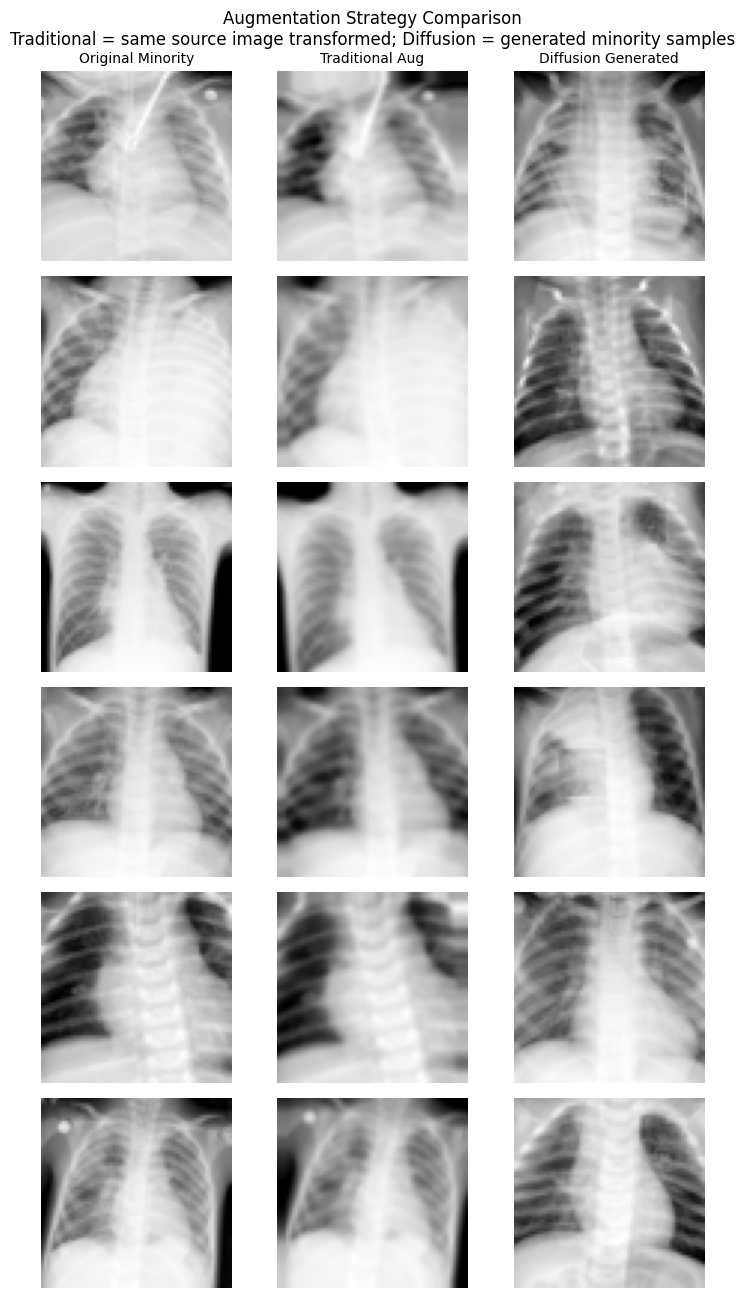

In [ ]:
# ==========================================================
# Solution 5.4: Final augmentation strategy comparison [2 pts]
# ==========================================================
print(
    "Note: the traditional column is a transformed version of the same original image. "
    "The diffusion column shows generated minority samples from the diffusion pool."
)
plot_augmentation_strategy_comparison(minority_images, aug_pipeline, generated_images, n=6)


## Part 6 — Reflection [5 pts]

> What are some potential risks or limitations of using diffusion-augmented images for medical image classification?

**Model Reflection Answer**

> One risk of using diffusion-augmented images for medical classification is that the generated images may contain artifacts or unrealistic patterns that are not present in real chest X-rays. If these artifacts are learned by the classifier, the model may improve on the training distribution but fail to generalize well to real medical images.

> Another limitation is that generated samples are not clinically validated. Even if they look reasonable visually, they may not preserve medically meaningful pneumonia features. Therefore, diffusion-generated images should be used only as training augmentation and should always be evaluated using unchanged real validation and test sets.

## Grading Rubric Summary (100 pts)

| Part | Section                                               | Points |
|----:|--------------------------------------------------------|------:|
| 1 | Load PneumoniaMNIST and create artificial imbalance      | 10 |
| 2 | Baseline CNN with checkpoint loading and fine-tuning      | 10 |
| 3 | Traditional augmentation CNN with checkpoint loading      | 10 |
| 4 | Diffusion inpainting augmentation workflow               | 50 |
| 5 | Metrics and model comparison                             | 15 |
| 6 | Reflection                                               | 5 |
|   | **Total**                                                | **100** |


## Grading Notes (Deductions Only)

- **Part 1: Load PneumoniaMNIST and Create Artificial Imbalance [10 pts]**
  - **1.1 Load and Preprocess PneumoniaMNIST [5 pts]**
    - Label mapping from `INFO["pneumoniamnist"]` not extracted or verified correctly **−1**
    - `MINORITY_CLASS` not verified as `"pneumonia"` **−1**
    - Train/validation/test splits not loaded correctly **−1**
    - Images not normalized to `[0, 1]` **−1**
    - Image shape/channel dimension handling incorrect **−1**

  - **1.2 Create an Imbalanced Training Dataset [5 pts]**
    - Minority and majority class masks incorrect **−1.5**
    - Does not keep all majority-class samples **−1**
    - Minority keep fraction applied incorrectly **−1**
    - Final imbalanced dataset not shuffled **−0.5**
    - Validation or test set modified during imbalance creation **−1**

- **Part 2: Baseline CNN with Checkpoint Loading and Fine-Tuning [10 pts]**
  - **2.1 Build the CNN Classifier Architecture [4 pts]**
    - Input shape `(IMG_SIZE, IMG_SIZE, 1)` missing or incorrect **−0.5**
    - Convolutional filter sequence `32 → 64 → 128 → 256` incorrect **−1**
    - Missing `BatchNormalization` or pooling structure **−1**
    - Missing `GlobalAveragePooling2D`, `Dense(128, relu)`, or `Dropout(0.4)` **−1**
    - Final `Dense(1, sigmoid)` or compile settings incorrect **−0.5**

  - **2.2 Load the Baseline Checkpoint and Fine-Tune [4 pts]**
    - Random seeds not reset before fine-tuning **−0.5**
    - Baseline `.keras` checkpoint not validated or loaded correctly **−1**
    - Loaded model not compiled for gentle fine-tuning **−1**
    - Training/validation `tf.data` datasets created incorrectly **−0.5**
    - Model not fine-tuned on the imbalanced training set **−1**

  - **2.3 Evaluate the Baseline Model [2 pts]**
    - Baseline model not evaluated on the unchanged test set **−1**
    - Confusion matrix missing or plotted from incorrect metrics **−0.5**
    - Prediction visualization missing **−0.5**

- **Part 3: Traditional Augmentation CNN with Checkpoint Loading and Fine-Tuning [10 pts]**
  - **3.1 Define the Traditional Augmentation Pipeline [3 pts]**
    - `keras.Sequential` augmentation pipeline missing or incorrect **−0.5**
    - Missing random rotation, translation, zoom, or contrast layer **−1**
    - Provided augmentation constants not used correctly **−1**
    - `fill_mode=TRAD_FILL_MODE` not used for geometric transforms **−0.5**

  - **3.2 Visualize Traditional Augmentation Examples [2 pts]**
    - Minority-class pneumonia samples not selected correctly **−0.75**
    - Augmentation pipeline not applied with training behavior enabled **−0.75**
    - Original and augmented images not visualized side by side **−0.5**

  - **3.3 Load the Traditional-Augmentation Checkpoint and Fine-Tune [3 pts]**
    - Traditional-augmentation `.keras` checkpoint not validated or loaded correctly **−1**
    - Loaded model not compiled for gentle fine-tuning **−0.75**
    - Augmented training dataset not created using `aug_pipeline` **−0.75**
    - Validation data augmented or not kept unchanged **−0.5**

  - **3.4 Evaluate the Traditional-Augmentation Model [2 pts]**
    - Model not evaluated on the unchanged test set **−1**
    - Confusion matrix missing or plotted from incorrect metrics **−1**

- **Part 4: Diffusion-Style Masked Denoising/Inpainting Augmentation [50 pts]**
  - **4.1 Define the Diffusion Noise Schedule [5 pts]**
    - Linear `betas` schedule incorrect **−1.5**
    - `alphas = 1 - betas` incorrect **−1**
    - `alpha_bars` cumulative product incorrect **−1.5**
    - Schedule arrays not converted to TensorFlow constants **−1**

  - **4.2 Reverse Diffusion Step [5 pts]**
    - Timestep batch handling incorrect **−1**
    - Noise prediction using the denoiser incorrect **−1**
    - Diffusion constants not gathered correctly for timestep `t` **−1**
    - Reverse-process mean equation incorrect **−1.5**
    - Noise added incorrectly at `t == 0` **−0.5**

  - **4.3 Image Inpainting with a Diffusion Model [10 pts]**
    - Random rectangular mask creation incorrect **−2**
    - Reverse diffusion loop implemented incorrectly **−2**
    - Masked region and unmasked source region combined incorrectly **−2**
    - Forward-noised source image not used correctly at intermediate timesteps **−2**
    - Final output not clipped to `[0, 1]` **−2**

  - **4.4 Fine-Tune a Pretrained Diffusion Denoiser [10 pts]**
    - Denoiser checkpoint not validated or loaded correctly **−2**
    - Denoiser not compiled with Adam and MSE loss **−1.5**
    - Minority-class pneumonia samples not selected correctly **−1.5**
    - Random timesteps or Gaussian noise not sampled correctly **−2**
    - Denoiser not trained to predict the added noise **−2**
    - Average loss not reported per epoch **−1**

  - **4.5 Generate Synthetic Minority-Class Samples [10 pts]**
    - Current minority count or target count computed incorrectly **−2**
    - Seed pneumonia images not selected correctly **−2**
    - `generate_inpainted_samples(...)` not used correctly **−2**
    - Generated labels not set to the minority class **−2**
    - Generated samples not visualized **−2**

  - **4.6 Fine-Tune and Evaluate the Diffusion-Augmented CNN [10 pts]**
    - Generated samples not combined with the training set correctly **−2**
    - Generated samples added to validation or test data **−3**
    - Diffusion-augmented checkpoint not validated or loaded correctly **−1.5**
    - Model not fine-tuned on the diffusion-augmented training set **−2**
    - Test evaluation or confusion matrix missing **−1.5**

- **Part 5: Metrics and Model Comparison [15 pts]**
  - **5.1 Model Comparison Table [5 pts]**
    - Missing baseline, traditional augmentation, or diffusion-augmented model results **−1.5**
    - Missing accuracy, macro-F1, minority precision, or minority recall **−2**
    - Uses stale/saved metrics instead of metrics from the current notebook run **−1**
    - Missing or unclear comparison of which model performs best overall **−0.5**

  - **5.2 Confusion Matrix Comparison [3 pts]**
    - Side-by-side confusion matrices missing **−1.5**
    - Class labels or model titles missing/unclear **−0.5**
    - Missing explanation of what improves over the baseline model **−1**

  - **5.3 Classification Reports [5 pts]**
    - Classification reports not printed for all three models **−1.5**
    - Precision, recall, or F1-score not included **−1**
    - Missing discussion of whether the diffusion model is more balanced across classes **−1.5**
    - Discussion ignores class-level performance and only reports overall accuracy **−1**

  - **5.4 Augmentation Strategy Comparison [2 pts]**
    - Original, traditional augmentation, and diffusion-generated samples not compared visually **−1**
    - Visualization is unclear or mislabeled **−0.5**
    - Missing short explanation of how traditional augmentation differs from diffusion augmentation **−0.5**

- **Part 6: Reflection [5 pts]**
  - Missing discussion of artifacts or unrealistic patterns in generated medical images **−1.5**
  - Missing discussion that generated medical images are not clinically validated **−1.5**
  - Missing explanation of why validation/test sets should remain real and unchanged **−1**
  - Overclaims that diffusion-generated images are clinically valid or always beneficial **−1**